# Supplier Risk & Performance Scoring

A sector-independent (non-defense) supply chain analytics project. This notebook walks through the full pipeline built in `src/`:

1. A synthetic, intentionally messy supplier dataset (generated with Faker for a Turkish SME/large-industry context)
2. Cleaning and standardizing that data with pandas
3. A custom, configurable weighted risk-scoring algorithm (0-100 score + Low/Medium/High label)
4. Visual exploration of the results
5. A sensitivity check: how much do the results change if the scoring weights change?

The scored output (`reports/supplier_risk_scores.csv`) is what feeds the Power BI dashboard.

In [1]:
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("../src")  # lets us import the scoring functions, not just the CSV outputs

sns.set_theme(style="whitegrid")
RISK_COLORS = {"Low": "#2ca02c", "Medium": "#ff9800", "High": "#d62728"}
RISK_ORDER = ["Low", "Medium", "High"]
pd.set_option("display.max_columns", None)

## 1. The raw data problem

Real supplier exports are rarely clean. To make that concrete (and to have something genuine to clean), `src/generate_suppliers.py` builds a synthetic dataset with the same problems a real Excel export from multiple ERP systems tends to have: mixed date formats, mixed decimal separators, inconsistent category labels, missing cells, and casing noise.

In [2]:
raw_df = pd.read_csv("../data/raw/suppliers_raw.csv", encoding="utf-8-sig")
print(f"{len(raw_df)} suppliers, {raw_df.shape[1]} columns")
raw_df.head()

85 suppliers, 19 columns


,supplier_id,company_name,sector,city,company_size,founded_year,annual_purchase_volume_tl,total_orders_last_year,late_orders_last_year,price_q1,price_q2,price_q3,price_q4,units_shipped_last_year,units_returned_last_year,contract_start_date,last_audit_date,payment_terms_days,iso_certified
0,SUP079,sakarya plastik ltd. şti.,Plastik ve Kauçuk,kocaeli,KÜÇÜK,2014.0,"1.133.007,83",25,7.0,371.31,394.71,"420,90",450.87,8653,1204.0,12/08/2023,02-02-25,30.0,false
1,SUP001,Korutürk Aslan Tekstil San. Tic. Ltd. Şti.,tekstil,Konya,orta,1980.0,15990835.27,134,38.0,322.41,"313,40",317.95,"281,45",46048,6596.0,31/07/2018,27.09.2024,30.0,evet
2,SUP069,akçay fırat elektrik san. ve tic. a.ş.,Elektronik,Izmir,ORTA,1982.0,3635127.73,74,20.0,212.99,199.02,"203,46","209,31",81987,7064.0,15/01/2023,NaN,45.0,No
3,SUP023,Sakarya Demir Celik Ltd. Sti.,Metal ve Çelik,Mersin,Small,2017.0,"1.171.021,60",58,5.0,"20,59","22,78","22,35",23.43,1688,233.0,24.08.2020,NaN,60.0,hayır
4,SUP013,şama holding a.ş.,Lojistik,Manisa,büyük,1977.0,NaN,164,23.0,"3.341,17",3313.66,3288.98,"3.435,07",214628,41843.0,NaN,24/04/2026,45.0,Evet


In [3]:
print("Raw 'company_size' labels actually found in the data (should be one value, not four):")
print(sorted(raw_df["company_size"].dropna().unique()))
print()

print("Raw 'contract_start_date' values (sample) — four different date formats mixed together:")
print(raw_df["contract_start_date"].dropna().sample(6, random_state=1).tolist())
print()

print("Raw 'price_q1' values (sample) — Turkish comma-decimal and plain dot-decimal mixed:")
print(raw_df["price_q1"].dropna().sample(6, random_state=2).tolist())
print()

print("Missing values per column:")
print(raw_df.isna().sum())

Raw 'company_size' labels actually found in the data (should be one value, not four):
['BÜYÜK', 'Büyük', 'KÜÇÜK', 'Küçük', 'Large', 'Medium', 'ORTA', 'Orta', 'Small', 'büyük', 'küçük', 'orta']

Raw 'contract_start_date' values (sample) — four different date formats mixed together:
['23/03/2021', '21/02/2023', '26/01/2020', '16.07.2022', '2018-06-05', '2023-11-23']

Raw 'price_q1' values (sample) — Turkish comma-decimal and plain dot-decimal mixed:
['383.65', '158,83', '3.153,69', '204,62', '3.781,60', '336.47']

Missing values per column:
supplier_id                   0
company_name                  0
sector                        0
city                          2
company_size                  0
founded_year                  8
annual_purchase_volume_tl     4
total_orders_last_year        0
late_orders_last_year         3
price_q1                      5
price_q2                      5
price_q3                      5
price_q4                      5
units_shipped_last_year       0
units_r

## 2. Cleaning approach

`src/clean_suppliers.py` fixes each problem with an explicit, auditable rule rather than a generic "guess and hope" transformation:

- **Numbers:** a small parser detects whether a value uses Turkish-style (`1.234,56`) or plain (`1234.56`) formatting and converts both to a real float.
- **Dates:** each value is tried against the four known raw formats until one matches.
- **Category columns** (`company_size`, `iso_certified`): matched against an explicit dictionary of every known raw variant (e.g. `küçük`/`KÜÇÜK`/`Small` all map to `Small`) — safer than case-insensitive string matching, which breaks on Turkish ı/İ (see below).
- **`sector` / `city`:** these come from a small closed list, so a messy value can be matched back to its correct canonical Turkish spelling even if it lost its diacritics or has odd casing.
- **`company_name`:** whitespace and casing are normalized, but a diacritic that was already lost upstream (e.g. `"Demir Celik"` instead of `"Demir Çelik"`) is **not** guessed back — the letter is ambiguous once lost, so guessing would just be a different kind of wrong data.

One genuine bug surfaced while building this: Python's default `str.lower()` is not Turkish-locale-aware. Lowercasing `'İ'` produces `'i'` followed by an invisible combining dot character (U+0307) instead of a plain `'i'` — a well-known Unicode/Turkish edge case. Left uncaught, this silently broke category matching. The fix (in `src/clean_suppliers.py`) strips stray combining marks before comparing strings.

In [4]:
clean_df = pd.read_csv("../data/processed/suppliers_clean.csv", encoding="utf-8-sig")

print("Standardized 'company_size' values:", sorted(clean_df["company_size"].dropna().unique()))
print("Standardized 'iso_certified' values:", clean_df["iso_certified"].dropna().unique().tolist())
print()
clean_df.head()

Standardized 'company_size' values: ['Large', 'Medium', 'Small']
Standardized 'iso_certified' values: [False, True]



,supplier_id,company_name,sector,city,company_size,founded_year,annual_purchase_volume_tl,total_orders_last_year,late_orders_last_year,price_q1,price_q2,price_q3,price_q4,units_shipped_last_year,units_returned_last_year,contract_start_date,last_audit_date,payment_terms_days,iso_certified
0,SUP079,Sakarya Plastik Ltd. Şti.,Plastik ve Kauçuk,Kocaeli,Small,2014.0,1133007.83,25,7.0,371.31,394.71,420.90,450.87,8653,1204.0,2023-08-12,2025-02-02,30.0,False
1,SUP001,Korutürk Aslan Tekstil San. Tic. Ltd. Şti.,Tekstil,Konya,Medium,1980.0,15990835.27,134,38.0,322.41,313.40,317.95,281.45,46048,6596.0,2018-07-31,2024-09-27,30.0,True
2,SUP069,Akçay Fırat Elektrik San. ve Tic. A.Ş.,Elektronik,İzmir,Medium,1982.0,3635127.73,74,20.0,212.99,199.02,203.46,209.31,81987,7064.0,2023-01-15,NaN,45.0,False
3,SUP023,Sakarya Demir Celik Ltd. Şti.,Metal ve Çelik,Mersin,Small,2017.0,1171021.60,58,5.0,20.59,22.78,22.35,23.43,1688,233.0,2020-08-24,NaN,60.0,False
4,SUP013,Şama Holding A.Ş.,Lojistik,Manisa,Large,1977.0,NaN,164,23.0,3341.17,3313.66,3288.98,3435.07,214628,41843.0,NaN,2026-04-24,45.0,True


## 3. Risk scoring methodology

Four criteria, each a standard building block of a real-world supplier scorecard:

| Criterion | What it measures | Default weight |
|---|---|---|
| `delivery_delay_rate` | Share of orders delivered late | 35% |
| `price_volatility` | Coefficient of variation of quarterly unit price | 25% |
| `supplier_dependency_ratio` | This supplier's share of total purchase volume (concentration risk) | 25% |
| `quality_return_rate` | Share of shipped units returned | 15% |

Weights are **not hardcoded** — they live in `config/scoring_weights.yaml` so anyone reusing this project can adapt them to their own priorities (the file is validated to always sum to 100%).

**Why min-max normalization?** The four raw metrics live on completely different scales (a 0-1 rate vs. a share of TL millions). Each metric is rescaled so the riskiest supplier on *that specific metric* scores 100 and the safest scores 0 — only then can they be combined with weights into one number.

**Why percentile-based Low/Medium/High cutoffs, not fixed score cutoffs?** A supplier is rarely the worst on all four metrics simultaneously, so combined scores cluster toward the middle of the range. A first attempt with a fixed cutoff (score > 66 = High) produced **zero** High-risk suppliers. Labeling the riskiest ~15% and safest ~60% of the *current* supplier population (percentile-based) always produces a meaningful spread, regardless of the underlying score range.

In [5]:
scores_df = pd.read_csv("../reports/supplier_risk_scores.csv", encoding="utf-8-sig")
scores_df.sort_values("risk_score", ascending=False).head(10)

,supplier_id,company_name,sector,city,company_size,delivery_delay_rate,price_volatility,supplier_dependency_ratio,quality_return_rate,delivery_delay_rate_score,price_volatility_score,supplier_dependency_ratio_score,quality_return_rate_score,risk_score,risk_level,has_estimated_inputs
0,SUP052,Çamurcuoğlu Sakarya Karton San. ve Tic. A.Ş.,Ambalaj,Gaziantep,Large,0.1953,0.0777,0.1206,0.1458,28.4,71.6,100.0,56.0,61.2,High,True
1,SUP007,Şensoy Sezer Oto Yedek Parça Ltd. Şti.,Otomotiv Yan Sanayi,Tekirdağ,Small,0.4348,0.0997,0.0005,0.1742,63.2,95.1,0.3,67.0,56.0,High,False
2,SUP045,Tevetoglu Holding A.Ş.,Lojistik,Mersin,Large,0.0442,0.0774,0.1188,0.1725,6.4,71.3,98.5,66.3,54.7,High,False
3,SUP070,Yüksel Bilgin Tekstil Tic.,Tekstil,Mersin,Small,0.4667,0.0833,0.0015,0.1819,67.9,77.6,1.2,70.0,53.9,High,False
4,SUP030,İhsanoğlu Şener Elektronik San. ve Tic. A.Ş.,Elektronik,İstanbul,Large,0.1186,0.0780,0.1128,0.1094,17.3,72.0,93.5,41.9,53.7,High,False
5,SUP051,İnönü Karton Ltd. Şti.,Ambalaj,Malatya,Small,0.6875,0.0421,0.0029,0.0751,100.0,33.7,2.3,28.7,48.3,High,True
6,SUP005,Bilir Holding A.Ş.,Elektronik,Mersin,Large,0.1987,0.0715,0.0469,0.1861,28.9,65.0,38.9,71.6,46.8,High,False
7,SUP073,Şener Yorulmaz Nakliyat Ltd. Şti.,Lojistik,Bursa,Small,0.3621,0.0596,0.0008,0.2107,52.7,52.3,0.6,81.1,43.8,High,False
8,SUP047,Gül Demir İplik San. Tic. Ltd. Şti.,Tekstil,Bursa,Medium,0.3452,0.0722,0.0161,0.0937,50.2,65.8,13.2,35.9,42.7,High,False
9,SUP079,Sakarya Plastik Ltd. Şti.,Plastik ve Kauçuk,Kocaeli,Small,0.2800,0.0836,0.0008,0.1391,40.7,78.0,0.6,53.4,41.9,High,False


## 4. Visual exploration

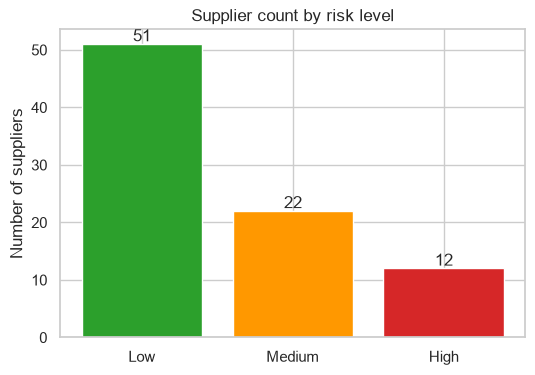

In [6]:
counts = scores_df["risk_level"].value_counts().reindex(RISK_ORDER)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(counts.index, counts.values, color=[RISK_COLORS[level] for level in RISK_ORDER])
ax.set_title("Supplier count by risk level")
ax.set_ylabel("Number of suppliers")
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.5, str(v), ha="center")
plt.show()

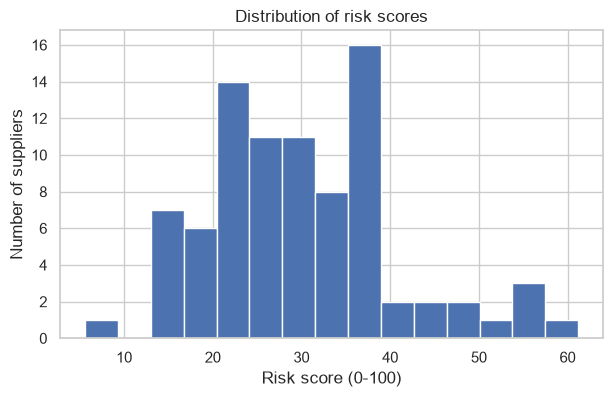

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(scores_df["risk_score"], bins=15, color="#4c72b0", edgecolor="white")
ax.set_title("Distribution of risk scores")
ax.set_xlabel("Risk score (0-100)")
ax.set_ylabel("Number of suppliers")
plt.show()

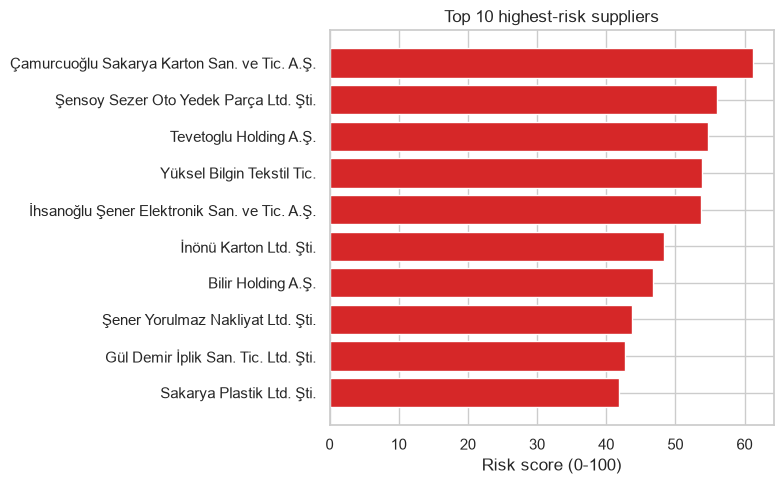

In [8]:
top10 = scores_df.sort_values("risk_score", ascending=False).head(10).iloc[::-1]
colors = [RISK_COLORS[level] for level in top10["risk_level"]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10["company_name"], top10["risk_score"], color=colors)
ax.set_title("Top 10 highest-risk suppliers")
ax.set_xlabel("Risk score (0-100)")
plt.tight_layout()
plt.show()

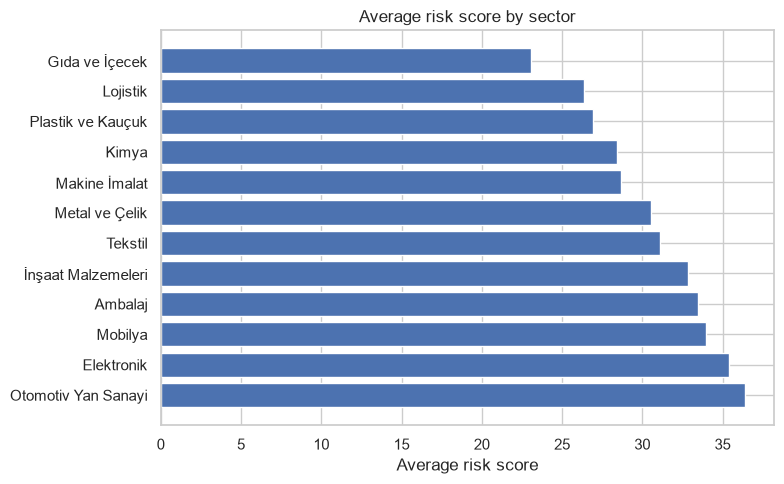

In [9]:
sector_avg = scores_df.groupby("sector")["risk_score"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(sector_avg.index, sector_avg.values, color="#4c72b0")
ax.set_title("Average risk score by sector")
ax.set_xlabel("Average risk score")
plt.tight_layout()
plt.show()

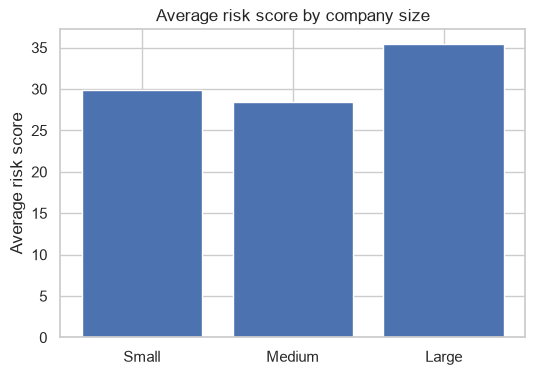

In [10]:
size_order = ["Small", "Medium", "Large"]
size_avg = scores_df.groupby("company_size")["risk_score"].mean().reindex(size_order)

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(size_avg.index, size_avg.values, color="#4c72b0")
ax.set_title("Average risk score by company size")
ax.set_ylabel("Average risk score")
plt.show()

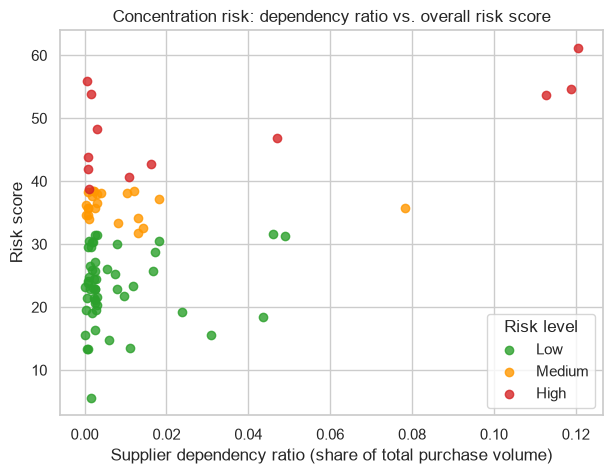

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
for level in RISK_ORDER:
    subset = scores_df[scores_df["risk_level"] == level]
    ax.scatter(subset["supplier_dependency_ratio"], subset["risk_score"],
               color=RISK_COLORS[level], label=level, alpha=0.8)
ax.set_xlabel("Supplier dependency ratio (share of total purchase volume)")
ax.set_ylabel("Risk score")
ax.set_title("Concentration risk: dependency ratio vs. overall risk score")
ax.legend(title="Risk level")
plt.show()

## 5. Weight sensitivity (bonus)

The scoring weights are a business decision, not a fixed fact — so it's worth checking how much the ranking actually changes if priorities shift. Below, the same cleaned data is re-scored under three weight profiles using the exact same `compute_metrics` / `compute_risk_score` functions from `src/score_suppliers.py` (proving the pipeline is genuinely reusable, not just a one-off script).

In [12]:
from score_suppliers import compute_metrics, compute_risk_score

metrics_df = compute_metrics(clean_df)

scenarios = {
    "Default (delivery-focused)": {
        "delivery_delay_rate": 0.35, "price_volatility": 0.25,
        "supplier_dependency_ratio": 0.25, "quality_return_rate": 0.15,
    },
    "Cost-focused": {
        "delivery_delay_rate": 0.15, "price_volatility": 0.45,
        "supplier_dependency_ratio": 0.25, "quality_return_rate": 0.15,
    },
    "Quality-focused": {
        "delivery_delay_rate": 0.20, "price_volatility": 0.15,
        "supplier_dependency_ratio": 0.15, "quality_return_rate": 0.50,
    },
}

comparison = pd.DataFrame({"company_name": metrics_df["company_name"]})
for name, weights in scenarios.items():
    config = {"weights": weights, "risk_level_thresholds": {"low_percentile": 0.60, "high_percentile": 0.85}}
    scored = compute_risk_score(metrics_df, config)
    comparison[name] = scored["risk_score"]

comparison.sort_values("Default (delivery-focused)", ascending=False).head(8)

,company_name,Default (delivery-focused),Cost-focused,Quality-focused
84,Çamurcuoğlu Sakarya Karton San. ve Tic. A.Ş.,61.2,69.9,59.4
48,Şensoy Sezer Oto Yedek Parça Ltd. Şti.,56.0,62.4,60.5
30,Tevetoglu Holding A.Ş.,54.7,67.7,59.9
35,Yüksel Bilgin Tekstil Tic.,53.9,55.9,60.4
72,İhsanoğlu Şener Elektronik San. ve Tic. A.Ş.,53.7,64.6,49.2
52,İnönü Karton Ltd. Şti.,48.3,35.0,39.7
8,Bilir Holding A.Ş.,46.8,54.0,57.2
13,Şener Yorulmaz Nakliyat Ltd. Şti.,43.8,43.7,59.0


## Key takeaways

- Of 85 synthetic suppliers, the pipeline flags 12 as **High** risk, 22 as **Medium**, and 51 as **Low**, using percentile-based cutoffs so the labels stay meaningful regardless of how the underlying scores are distributed.
- The single highest-risk supplier is high-risk mainly because of **concentration risk**: it alone accounts for ~12% of total purchase volume, so its `supplier_dependency_ratio` score is 100/100 — a concrete, explainable driver, not a black box.
- Scoring weights are configurable (`config/scoring_weights.yaml`), and re-running the same scoring functions under different weight profiles shows the ranking is genuinely sensitive to business priorities — e.g. a cost-focused company would flag a different top-risk supplier than a delivery-focused one.
- Cleaning decisions were made explicitly and conservatively: structured fields (sector, city, category labels) were fully recovered via canonical matching, while free-text fields with already-lost information (company name diacritics) were left as-is rather than guessed — an intentional, documented data-quality boundary.